In [1]:
# required libraries
import pandas as pd

In [2]:
df = pd.read_csv("adnimerge.csv", low_memory=False)
# print(df)
df.describe()

,RID,SITE,AGE,PTEDUCAT,APOE4,FDG,PIB,AV45,FBB,CDRSB,...,EcogSPDivatt_bl,EcogSPTotal_bl,FDG_bl,PIB_bl,AV45_bl,FBB_bl,Years_bl,Month_bl,Month,M
count,16421.000000,16421.000000,16412.000000,16421.000000,16056.000000,3693.000000,223.000000,3080.000000,513.000000,11747.000000,...,8915.000000,9085.000000,11220.000000,154.000000,7836.000000,1099.000000,16421.000000,16421.000000,16421.000000,16421.000000
mean,2899.082273,81.733329,73.214173,16.105779,0.516193,1.175624,1.783161,1.193030,1.175212,2.047927,...,1.735025,1.601863,1.226786,1.582256,1.186525,1.163109,2.738280,32.792027,32.712259,32.580903
std,2220.442824,132.762777,7.028099,2.762672,0.646953,0.167288,0.422511,0.230866,0.246133,2.866563,...,0.861453,0.670951,0.153364,0.302114,0.220110,0.236850,2.939675,35.203809,35.193789,35.124178
min,2.000000,2.000000,50.400000,4.000000,0.000000,0.566989,1.095000,0.809000,0.870200,0.000000,...,1.000000,1.000000,0.621933,1.155000,0.810000,0.870200,0.000000,0.000000,0.000000,0.000000
25%,751.000000,22.000000,68.500000,14.000000,0.000000,1.071700,1.361250,1.010075,0.996900,0.000000,...,1.000000,1.102560,1.134820,1.360000,1.012400,0.995100,0.506502,6.065570,6.000000,6.000000
50%,2308.000000,41.000000,73.200000,16.000000,0.000000,1.180590,1.850000,1.106800,1.054000,1.000000,...,1.500000,1.333330,1.234580,1.490000,1.098400,1.041700,1.960300,23.475400,24.000000,24.000000
75%,4707.000000,123.000000,78.100000,18.000000,1.000000,1.287080,2.127500,1.358425,1.350800,3.000000,...,2.000000,1.897440,1.331470,1.835000,1.346900,1.318600,4.010950,48.032800,48.000000,48.000000
max,7125.000000,941.000000,91.400000,20.000000,2.000000,1.776170,2.927500,2.686600,2.008800,18.000000,...,4.000000,3.948720,1.776170,2.282500,2.010100,1.909000,16.961000,203.115000,204.000000,204.000000


In [3]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Cell 2: Load Data (Strictly CSF Biomarkers)
# Replace 'adnimerge.csv' with your actual file path if it's in a different folder
df = pd.read_csv('adnimerge.csv')

# Define the target
target_col = 'DX'  # 'DX' is the diagnosis at the current visit (CN, MCI, Dementia)

# Define strictly the CSF biomarker features
biomarker_features = [
    'ABETA',  # Amyloid beta (CSF)
    'TAU',    # Total Tau (CSF)
    'PTAU'    # Phosphorylated Tau (CSF)
]

# Create a subset of the data
df_model = df[['RID', 'VISCODE', target_col] + biomarker_features].copy()

print(f"Initial shape: {df_model.shape}")
display(df_model.head())

Initial shape: (16421, 6)


,RID,VISCODE,DX,ABETA,TAU,PTAU
0,2,bl,CN,NaN,NaN,NaN
1,3,bl,Dementia,741.5,239.7,22.83
2,3,m06,Dementia,NaN,NaN,NaN
3,3,m12,Dementia,601.4,251.7,24.18
4,3,m24,Dementia,NaN,NaN,NaN


In [5]:
# Cell 3: Data Cleaning
# 1. Drop rows where the target diagnosis is missing
df_model = df_model.dropna(subset=[target_col])

# 2. Convert biomarker columns to numeric
# The errors='coerce' argument will turn strings like '>1200' into NaN, 
# which we will handle in the imputation step.
for col in biomarker_features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# 3. Check the distribution of our target variable
print("Class distribution for target (DX):")
print(df_model[target_col].value_counts())

# Define X (features) and y (target)
X = df_model[biomarker_features]
y = df_model[target_col]

Class distribution for target (DX):
DX
MCI         4989
CN          4020
Dementia    2449
Name: count, dtype: int64


In [6]:
# Cell 4: Splitting and Imputation
# 1. Split the data (80% training, 20% testing)
# stratify=y ensures the class balance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. Impute missing values
# We use the median because medical data is often skewed
imputer = SimpleImputer(strategy='median')

# Fit on training data, then transform both train and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. Scale the features (Standardization)
# Algorithms perform better when numerical features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (9166, 3)
Testing features shape: (2292, 3)


In [7]:
# Cell 5: Initialize and Train the Model
# We use class_weight='balanced' in case one diagnosis (like MCI) vastly outnumbers the others
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_classifier.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


Accuracy Score: 0.38699825479930194

Classification Report:
               precision    recall  f1-score   support

          CN       0.37      0.90      0.52       804
    Dementia       0.51      0.10      0.16       490
         MCI       0.50      0.11      0.18       998

    accuracy                           0.39      2292
   macro avg       0.46      0.37      0.29      2292
weighted avg       0.45      0.39      0.30      2292



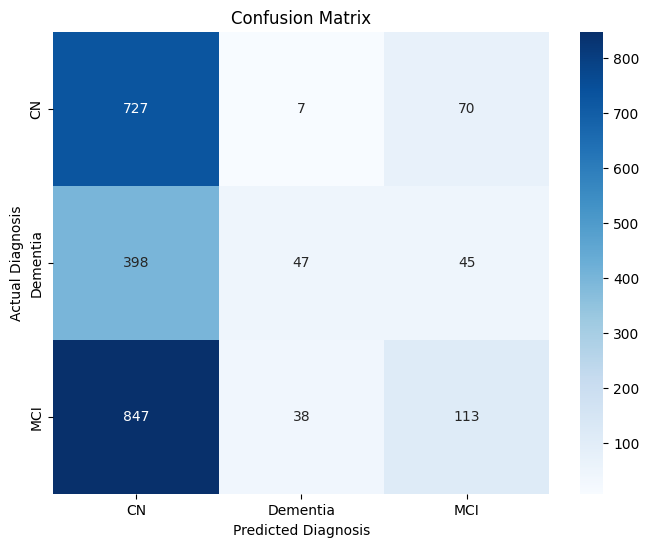

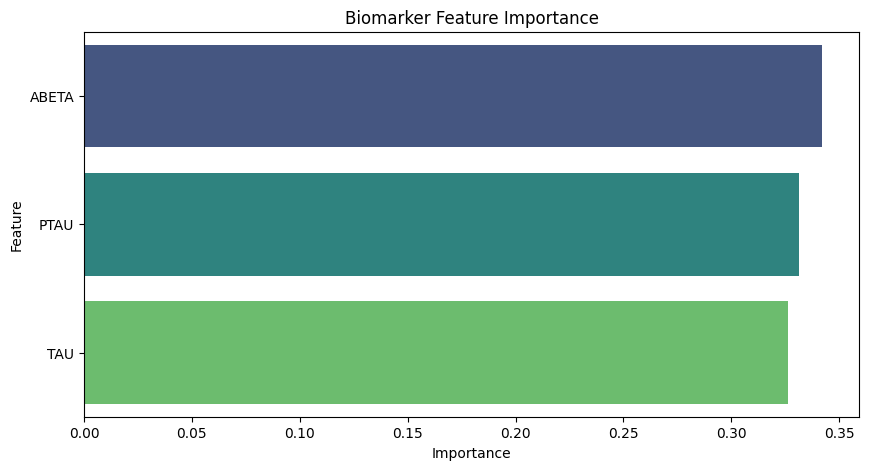

In [8]:
# Cell 6: Predictions and Evaluation
# Make predictions
y_pred = rf_classifier.predict(X_test_scaled)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=rf_classifier.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_classifier.classes_, 
            yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance
feature_importances = rf_classifier.feature_importances_
importance_df = pd.DataFrame({
    'Feature': biomarker_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Biomarker Feature Importance')
plt.show()

In [9]:
# ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


# Simce there are dataset where the CSF are absent and after filling it with the median makes the data skewed



In [10]:
# Cell 3: Data Cleaning (UPDATED with variable suffixes)

# Create a fresh copy so we DO NOT alter the previous df_model
df_model2 = df_model.copy()

# 1. Drop rows where the target diagnosis is missing
df_model2 = df_model2.dropna(subset=[target_col])

# 2. Convert biomarker columns to numeric (forces text values to NaN)
for col in biomarker_features:
    df_model2[col] = pd.to_numeric(df_model2[col], errors='coerce')

# 3. CRITICAL FIX: Drop rows that do not have actual CSF data
df_model2 = df_model2.dropna(subset=biomarker_features, how='any')

print("Class distribution for target (DX) AFTER dropping missing CSF data:")
print(df_model2[target_col].value_counts())

# Define X2 and y2 from the new cleaned dataframe
X2 = df_model2[biomarker_features]
y2 = df_model2[target_col]

Class distribution for target (DX) AFTER dropping missing CSF data:
DX
MCI         916
CN          578
Dementia    509
Name: count, dtype: int64


In [11]:
# Cell 4: Splitting and Imputation
# 1. Split the data (80% training, 20% testing) using X2 and y2 from Cell 3
# stratify=y2 ensures the class balance is maintained in both sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42, stratify=y2)

# 2. Impute missing values
# Note: Since we used dropna() in Cell 3, there are no missing values left,
# but keeping this step ensures the structure is preserved without breaking anything.
imputer2 = SimpleImputer(strategy='median')

# Fit on training data, then transform both train and test data
X_train_imputed2 = imputer2.fit_transform(X_train2)
X_test_imputed2 = imputer2.transform(X_test2)

# 3. Scale the features (Standardization)
# Fixed: Changed 'scaler' to 'scaler2' to use the newly initialized scaler object
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train_imputed2)
X_test_scaled2 = scaler2.transform(X_test_imputed2)

print(f"Training features shape: {X_train_scaled2.shape}")
print(f"Testing features shape: {X_test_scaled2.shape}")

Training features shape: (1602, 3)
Testing features shape: (401, 3)


In [12]:
# Cell 5: Initialize and Train the Model
# We use class_weight='balanced' in case one diagnosis (like MCI) vastly outnumbers the others
rf_classifier2 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model using the updated training datasets from Cell 4
rf_classifier2.fit(X_train_scaled2, y_train2)

print("Model 2 training complete.")

Model 2 training complete.


Accuracy Score: 0.4688279301745636

Classification Report:
               precision    recall  f1-score   support

          CN       0.45      0.46      0.45       116
    Dementia       0.47      0.46      0.46       102
         MCI       0.48      0.48      0.48       183

    accuracy                           0.47       401
   macro avg       0.47      0.47      0.47       401
weighted avg       0.47      0.47      0.47       401



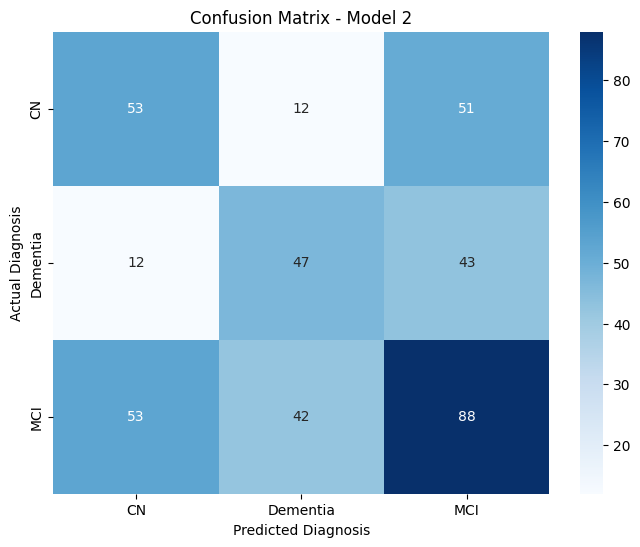

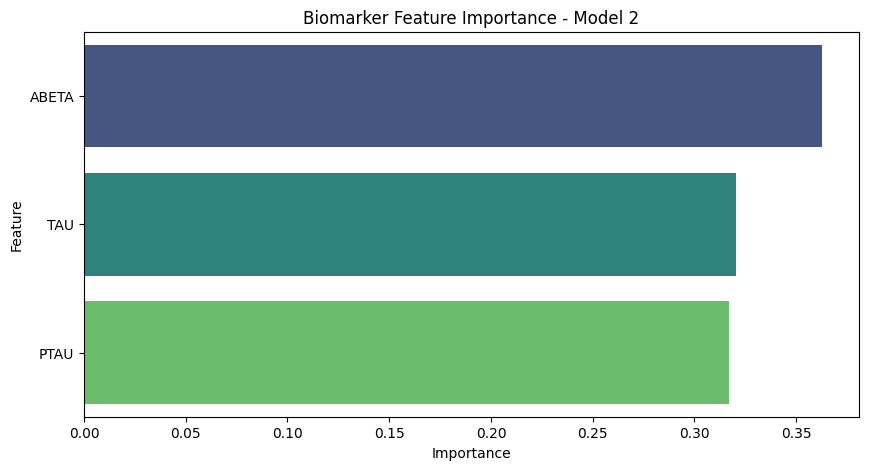

In [13]:
# Cell 6: Predictions and Evaluation
# Make predictions using Model 2 and the scaled test features from Cell 4
y_pred2 = rf_classifier2.predict(X_test_scaled2)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test2, y_pred2))
print("\nClassification Report:\n", classification_report(y_test2, y_pred2))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm2 = confusion_matrix(y_test2, y_pred2, labels=rf_classifier2.classes_)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_classifier2.classes_, 
            yticklabels=rf_classifier2.classes_)
plt.title('Confusion Matrix - Model 2')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance
feature_importances2 = rf_classifier2.feature_importances_
importance_df2 = pd.DataFrame({
    'Feature': biomarker_features,
    'Importance': feature_importances2
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df2, palette='viridis')
plt.title('Biomarker Feature Importance - Model 2')
plt.show()